In [2]:
# Imports and GPU check
import json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout, Flatten, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping
import gensim.downloader as api

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.20.0
GPU available: []


In [3]:
# Load and inspect dataset
with open("News_Category_Dataset_v3.json", "r") as f:
    data = [json.loads(line) for line in f]

df = pd.DataFrame(data)[['category', 'headline']]
df['category'] = df['category'].str.upper() #Uppercase consistency

# Display total number of rows
print(f"Total number of records in the dataset: {len(df)}")

# Show first 5 rows
print("First 5 rows:")
print(df.head())

Total number of records in the dataset: 209527
First 5 rows:
    category                                           headline
0  U.S. NEWS  Over 4 Million Americans Roll Up Sleeves For O...
1  U.S. NEWS  American Airlines Flyer Charged, Banned For Li...
2     COMEDY  23 Of The Funniest Tweets About Cats And Dogs ...
3  PARENTING  The Funniest Tweets From Parents This Week (Se...
4  U.S. NEWS  Woman Who Called Cops On Black Bird-Watcher Lo...


In [4]:
print("\nUnique categories:")
print(df['category'].unique())


Unique categories:
['U.S. NEWS' 'COMEDY' 'PARENTING' 'WORLD NEWS' 'CULTURE & ARTS' 'TECH'
 'SPORTS' 'ENTERTAINMENT' 'POLITICS' 'WEIRD NEWS' 'ENVIRONMENT'
 'EDUCATION' 'CRIME' 'SCIENCE' 'WELLNESS' 'BUSINESS' 'STYLE & BEAUTY'
 'FOOD & DRINK' 'MEDIA' 'QUEER VOICES' 'HOME & LIVING' 'WOMEN'
 'BLACK VOICES' 'TRAVEL' 'MONEY' 'RELIGION' 'LATINO VOICES' 'IMPACT'
 'WEDDINGS' 'COLLEGE' 'PARENTS' 'ARTS & CULTURE' 'STYLE' 'GREEN' 'TASTE'
 'HEALTHY LIVING' 'THE WORLDPOST' 'GOOD NEWS' 'WORLDPOST' 'FIFTY' 'ARTS'
 'DIVORCE']


In [5]:
print("\nNull values:\n", df.isnull().sum())


Null values:
 category    0
headline    0
dtype: int64


In [6]:
# Define target categories
target_categories = ['POLITICS', 'BUSINESS', 'SPORTS']

# Extract exactly first 5,000 records per category
dfs = []
for cat in target_categories:
    subset = df[df['category'].str.upper() == cat]
    count = len(subset)
    print(f"{cat}: Found {count} records. Extracting first 5,000.")
    dfs.append(subset.head(5000))

# Combine into one balanced DataFrame
df_selected = pd.concat(dfs, ignore_index=True)
df_selected['category'] = df_selected['category'].str.upper()

# Confirm shape and per-class counts
print("\nBalanced dataset shape:", df_selected.shape)
print("Per-class counts:")
print(df_selected['category'].value_counts())

# Show first 5 rows from each category
for cat in target_categories:
    print(f"\nFirst 5 rows from category: {cat}")
    display(df_selected[df_selected['category'] == cat][['headline', 'category']].head())

POLITICS: Found 35602 records. Extracting first 5,000.
BUSINESS: Found 5992 records. Extracting first 5,000.
SPORTS: Found 5077 records. Extracting first 5,000.

Balanced dataset shape: (15000, 2)
Per-class counts:
category
POLITICS    5000
BUSINESS    5000
SPORTS      5000
Name: count, dtype: int64

First 5 rows from category: POLITICS


,headline,category
0,Biden Says U.S. Forces Would Defend Taiwan If ...,POLITICS
1,‘Beautiful And Sad At The Same Time’: Ukrainia...,POLITICS
2,Biden Says Queen's Death Left 'Giant Hole' For...,POLITICS
3,Bill To Help Afghans Who Escaped Taliban Faces...,POLITICS
4,Mark Meadows Complies With Justice Dept. Subpo...,POLITICS



First 5 rows from category: BUSINESS


,headline,category
5000,REI Workers At Berkeley Store Vote To Unionize...,BUSINESS
5001,Twitter Lawyer Calls Elon Musk 'Committed Enem...,BUSINESS
5002,"Starbucks Leaving Russian Market, Shutting 130...",BUSINESS
5003,Crypto Crash Leaves Trading Platform Coinbase ...,BUSINESS
5004,"US Added 428,000 Jobs In April Despite Surging...",BUSINESS



First 5 rows from category: SPORTS


,headline,category
10000,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
10001,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS
10002,Boston Marathon To Make Race More Inclusive Fo...,SPORTS
10003,"Anthony Varvaro, MLB Pitcher Turned Transit Co...",SPORTS
10004,Carlos Alcaraz Wins U.S. Open For 1st Slam Tit...,SPORTS


In [7]:
# Preprocessing and longest headline
from bs4 import BeautifulSoup

def clean_text(text):
    text = str(text)
    text = BeautifulSoup(text, "html.parser").get_text()  # removes HTML tags
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_selected['clean'] = df_selected['headline'].apply(clean_text)
df_selected['token_count'] = df_selected['clean'].apply(lambda x: len(x.split()))
longest = df_selected.loc[df_selected['token_count'].idxmax()]
print(f"Longest headline ({longest['token_count']} tokens):\n{longest['headline']}")
MAX_LEN = df_selected['token_count'].max()

C:\Users\shrey\AppData\Local\Temp\ipykernel_6252\2478449815.py:6: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  text = BeautifulSoup(text, "html.parser").get_text()  # removes HTML tags


Longest headline (30 tokens):
Women in Business: Nancy Mahon, Senior Vice President, Global Philanthropy and Corporate Citizenship, for The Estée Lauder Companies Inc. and Global Director of the M·A·C AIDS Fund


In [8]:
# Label encoding and stratified split
label_map = {cat: i for i, cat in enumerate(target_categories)}
labels = df_selected['category'].map(label_map).values
texts = df_selected['clean'].tolist()

X_temp, X_test, y_temp, y_test = train_test_split(texts, labels, test_size=0.20, stratify=labels, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.10, stratify=y_temp, random_state=42)

In [9]:
print("Total records:", len(texts))
print("Training set size:", len(X_train))
print("Validation set size:", len(X_val))
print("Test set size:", len(X_test))

Total records: 15000
Training set size: 10800
Validation set size: 1200
Test set size: 3000


In [10]:
# Tokenizer and dynamic vocab size
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)
raw_vocab_size = len(tokenizer.word_index) + 1
MAX_NUM_WORDS = min(20000, raw_vocab_size)
print("Raw vocab size:", raw_vocab_size)
print("Capped vocab size:", MAX_NUM_WORDS)

tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

def tokenize_and_pad(texts):
    seq = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

X_train_pad = tokenize_and_pad(X_train)
X_val_pad = tokenize_and_pad(X_val)
X_test_pad = tokenize_and_pad(X_test)

Raw vocab size: 16194
Capped vocab size: 16194


In [11]:
# Load Word2Vec and build embedding matrix
w2v = api.load("word2vec-google-news-300")
embedding_dim = 300
embedding_matrix = np.zeros((MAX_NUM_WORDS, embedding_dim))
missing = []

for word, i in tokenizer.word_index.items():
    if i < MAX_NUM_WORDS:
        try:
            embedding_matrix[i] = w2v[word]
        except KeyError:
            missing.append(word)

print(f"Missing words from Word2Vec: {len(missing)}")

[==========================------------------------] 53.2% 883.9/1662.8MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[===========================================-------] 86.9% 1444.8/1662.8MB downloadedMissing words from Word2Vec: 4279


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout, GlobalAveragePooling1D, SimpleRNN, LSTM, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

def build_ffn():
    model = Sequential([
        Embedding(MAX_NUM_WORDS, embedding_dim, weights=[embedding_matrix], input_length=MAX_LEN, trainable=False),
        GlobalAveragePooling1D(),
        Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-3)),
        Dropout(0.4),
        Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(0.3),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_rnn():
    model = Sequential([
        Embedding(MAX_NUM_WORDS, embedding_dim, weights=[embedding_matrix], input_length=MAX_LEN, trainable=False),
        SimpleRNN(128, dropout=0.3, recurrent_dropout=0.0),
        Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(0.3),
        Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(0.2),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_lstm():
    model = Sequential([
        Embedding(MAX_NUM_WORDS, embedding_dim, weights=[embedding_matrix], input_length=MAX_LEN, trainable=False),
        LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2),
        LSTM(64, dropout=0.3, recurrent_dropout=0.2),
        Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(0.3),
        Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(0.2),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [13]:
def train_model(model, name):
    print(f"\nTraining {name}...")
    model.build(input_shape=(None, MAX_LEN))  # Ensures summary is complete
    model.summary()
    history = model.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=50,
        batch_size=256,
        callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
        verbose=2
    )
    return model, history

In [14]:
ffn_model, hist_ffn = train_model(build_ffn(), "FFN")
rnn_model, hist_rnn = train_model(build_rnn(), "RNN")
lstm_model, hist_lstm = train_model(build_lstm(), "LSTM")

C:\Users\shrey\miniconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Training FFN...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 30, 300)             │       4,858,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 300)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          38,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,900,955 (18.70 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 30, 300)             │       4,858,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 30, 128)             │         219,648 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,133,595 (19.58 MB)

 Trainable params: 275,395 (1.05 MB)

 Non-trainable params: 4,858,200 (18.53 MB)

Epoch 1/50
43/43 - 30s - 695ms/step - accuracy: 0.4682 - loss: 1.0237 - val_accuracy: 0.6892 - val_loss: 0.8070
Epoch 2/50
43/43 - 18s - 418ms/step - accuracy: 0.7638 - loss: 0.6584 - val_accuracy: 0.8292 - val_loss: 0.4752
Epoch 3/50
43/43 - 9s - 210ms/step - accuracy: 0.8227 - loss: 0.5241 - val_accuracy: 0.8583 - val_loss: 0.4074
Epoch 4/50
43/43 - 10s - 232ms/step - accuracy: 0.8331 - loss: 0.4969 - val_accuracy: 0.8458 - val_loss: 0.3976
Epoch 5/50
43/43 - 9s - 206ms/step - accuracy: 0.8406 - loss: 0.4705 - val_accuracy: 0.8600 - val_loss: 0.3828
Epoch 6/50
43/43 - 9s - 206ms/step - accuracy: 0.8424 - loss: 0.4576 - val_accuracy: 0.8567 - val_loss: 0.3728
Epoch 7/50
43/43 - 8s - 198ms/step - accuracy: 0.8450 - loss: 0.4443 - val_accuracy: 0.8608 - val_loss: 0.3711
Epoch 8/50
43/43 - 8s - 195ms/step - accuracy: 0.8450 - loss: 0.4389 - val_accuracy: 0.8617 - val_loss: 0.3763
Epoch 9/50
43/43 - 10s - 244ms/step - accuracy: 0.8506 - loss: 0.4278 - val_accuracy: 0.8625 - val_loss: 0.36

In [15]:
# Evaluate test accuracy for each model
acc_ffn = ffn_model.evaluate(X_test_pad, y_test, verbose=0)[1]
acc_rnn = rnn_model.evaluate(X_test_pad, y_test, verbose=0)[1]
acc_lstm = lstm_model.evaluate(X_test_pad, y_test, verbose=0)[1]

print(f"FFN Test Accuracy: {acc_ffn:.4f}")
print(f"RNN Test Accuracy: {acc_rnn:.4f}")
print(f"LSTM Test Accuracy: {acc_lstm:.4f}")

FFN Test Accuracy: 0.8697
RNN Test Accuracy: 0.8613
LSTM Test Accuracy: 0.8893


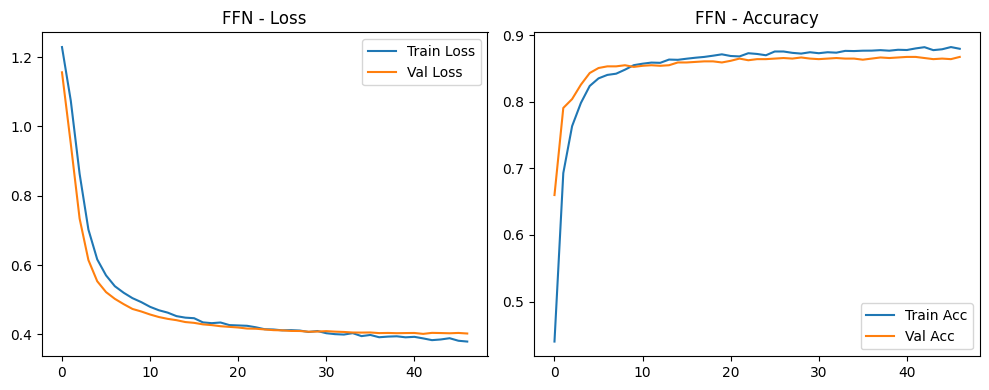

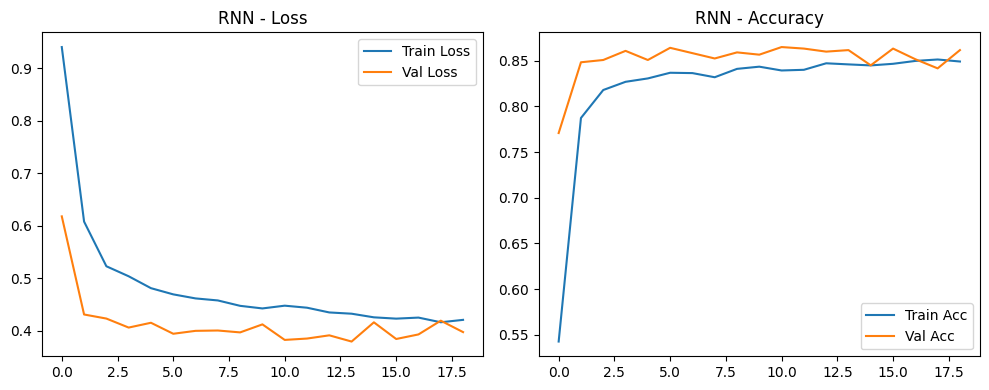

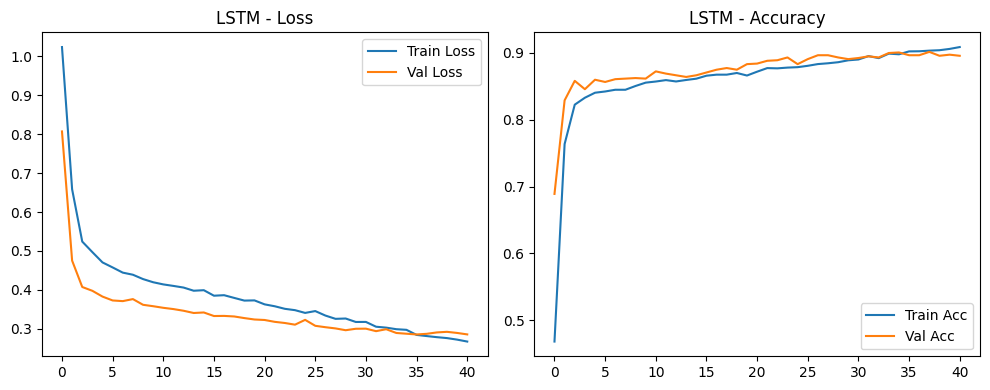

In [16]:
# Plot training history
def plot_history(hist, title):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(hist.history['loss'], label='Train Loss')
    plt.plot(hist.history['val_loss'], label='Val Loss')
    plt.title(f"{title} - Loss"); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(hist.history['accuracy'], label='Train Acc')
    plt.plot(hist.history['val_accuracy'], label='Val Acc')
    plt.title(f"{title} - Accuracy"); plt.legend()
    plt.tight_layout(); plt.show()

plot_history(hist_ffn, "FFN")
plot_history(hist_rnn, "RNN")
plot_history(hist_lstm, "LSTM")

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

FFN Classification Report:
POLITICS: Precision=0.8692, Recall=0.8570, F1=0.8630
BUSINESS: Precision=0.8426, Recall=0.8830, F1=0.8623
SPORTS: Precision=0.8996, Recall=0.8690, F1=0.8840

Micro avg: Precision=0.8697, Recall=0.8697, F1=0.8697
Macro avg: Precision=0.8704, Recall=0.8697, F1=0.8698


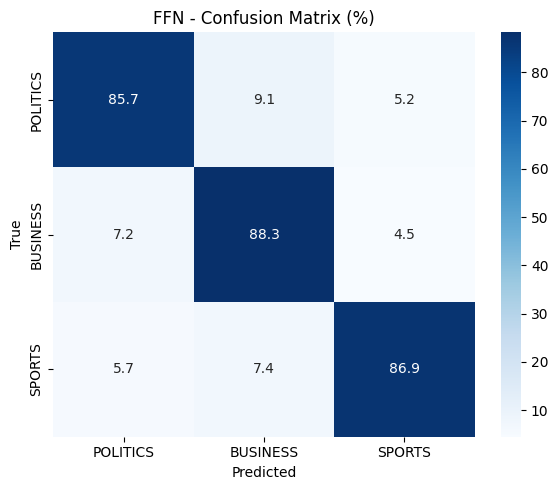

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step

RNN Classification Report:
POLITICS: Precision=0.8874, Recall=0.8120, F1=0.8480
BUSINESS: Precision=0.8341, Recall=0.8950, F1=0.8635
SPORTS: Precision=0.8666, Recall=0.8770, F1=0.8718

Micro avg: Precision=0.8613, Recall=0.8613, F1=0.8613
Macro avg: Precision=0.8627, Recall=0.8613, F1=0.8611


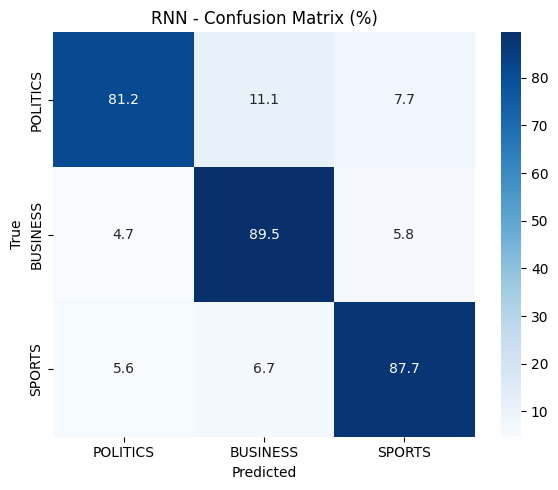

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step

LSTN Classification Report:
POLITICS: Precision=0.9156, Recall=0.8460, F1=0.8794
BUSINESS: Precision=0.8459, Recall=0.9280, F1=0.8851
SPORTS: Precision=0.9132, Recall=0.8940, F1=0.9035

Micro avg: Precision=0.8893, Recall=0.8893, F1=0.8893
Macro avg: Precision=0.8916, Recall=0.8893, F1=0.8893


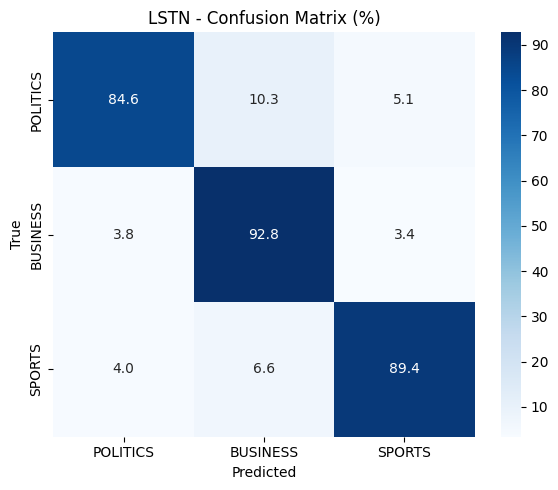

In [17]:
# Evaluate models
def evaluate_model(model, X_test, y_test, name):
    y_pred = np.argmax(model.predict(X_test), axis=1)
    report = classification_report(y_test, y_pred, target_names=target_categories, digits=4, output_dict=True)
    micro = precision_recall_fscore_support(y_test, y_pred, average='micro')
    macro = precision_recall_fscore_support(y_test, y_pred, average='macro')
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100.0

    print(f"\n{name} Classification Report:")
    for cls in target_categories:
        r = report[cls]
        print(f"{cls}: Precision={r['precision']:.4f}, Recall={r['recall']:.4f}, F1={r['f1-score']:.4f}")
    print(f"\nMicro avg: Precision={micro[0]:.4f}, Recall={micro[1]:.4f}, F1={micro[2]:.4f}")
    print(f"Macro avg: Precision={macro[0]:.4f}, Recall={macro[1]:.4f}, F1={macro[2]:.4f}")

    plt.figure(figsize=(6,5))
    sns.heatmap(cm_norm, annot=True, fmt=".1f", cmap="Blues",
                xticklabels=target_categories, yticklabels=target_categories)
    plt.title(f"{name} - Confusion Matrix (%)")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout(); plt.show()

evaluate_model(ffn_model, X_test_pad, y_test, "FFN")
evaluate_model(rnn_model, X_test_pad, y_test, "RNN")
evaluate_model(lstm_model, X_test_pad, y_test, "LSTN")

C:\Users\shrey\miniconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\shrey\miniconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\shrey\miniconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\shrey\miniconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\shrey\miniconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.Crea

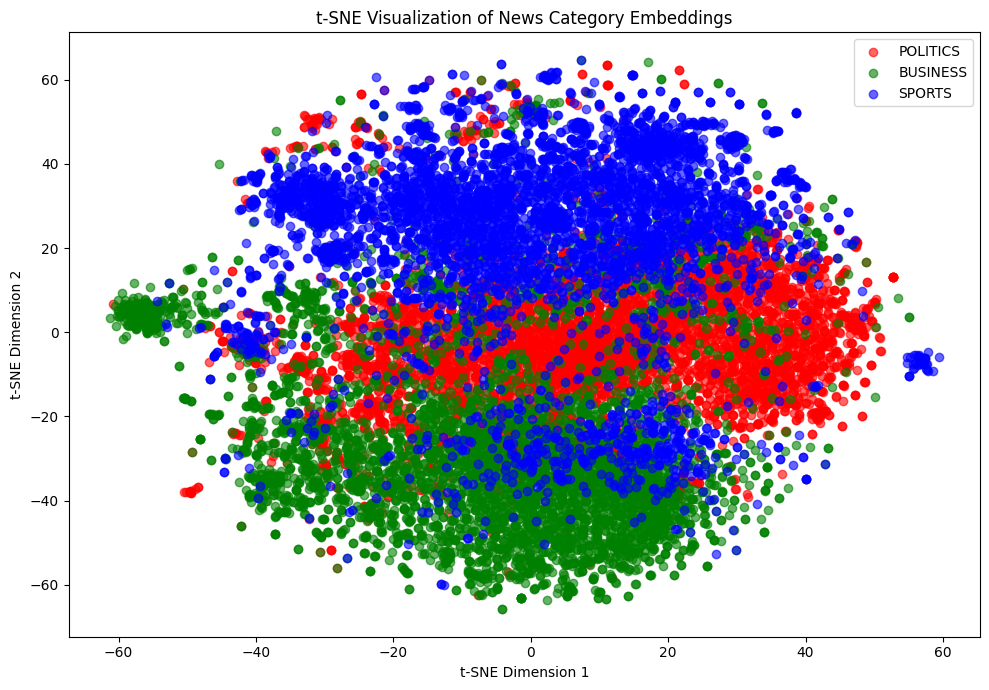

In [18]:
from sklearn.manifold import TSNE

# Step 1: Create document-level embeddings by averaging Word2Vec vectors
def get_doc_vector(text, model):
    words = [w for w in text.split() if w in model]
    if not words:
        return np.zeros(300)
    return np.mean([model[w] for w in words], axis=0)

doc_vectors = np.array([get_doc_vector(text, w2v) for text in df_selected['clean']])
labels = df_selected['category'].values

# Step 2: Apply t-SNE to reduce to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=40)
tsne_results = tsne.fit_transform(doc_vectors)

# Step 3: Plot the results
plt.figure(figsize=(10, 7))
palette = {'POLITICS': 'red', 'BUSINESS': 'green', 'SPORTS': 'blue'}
for category in target_categories:
    idx = labels == category
    plt.scatter(tsne_results[idx, 0], tsne_results[idx, 1], 
                label=category, alpha=0.6, c=palette[category])

plt.title("t-SNE Visualization of News Category Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.tight_layout()
plt.savefig("tsne_news_categories.png")
plt.show()

In [19]:
# =====================================================================
# EXPORT ARTIFACTS FOR DEPLOYMENT
# Paste this as the LAST cell of Mondal_HW2.ipynb and run it after the
# notebook has run top to bottom (it uses lstm_model, tokenizer, MAX_LEN,
# missing, target_categories, X_test_pad, y_test, X_test from earlier cells).
# It writes everything the API needs into a "models/" folder.
# =====================================================================
import os, json, sys, platform
import numpy as np
import tensorflow as tf
import keras
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

EXPORT_DIR = "models"
os.makedirs(EXPORT_DIR, exist_ok=True)

# 1) The trained LSTM (best model: ~90% test accuracy)
lstm_model.save(os.path.join(EXPORT_DIR, "news_lstm.keras"))

# 2) Preprocessing config as plain JSON.
#    The API re-implements the tokenizer from this file, so serving does not
#    depend on the (deprecated) Keras Tokenizer class.
preprocessing = {
    "word_index": tokenizer.word_index,
    "num_words": tokenizer.num_words,
    "oov_token": tokenizer.oov_token,
    "filters": tokenizer.filters,
    "lower": tokenizer.lower,
    "split": tokenizer.split,
    "max_len": int(MAX_LEN),
    "padding": "post",
    "truncating": "post",
    "labels": list(target_categories),  # position = class index
}
with open(os.path.join(EXPORT_DIR, "preprocessing.json"), "w") as f:
    json.dump(preprocessing, f)

# 3) Words that are in the vocabulary but have no Word2Vec vector
#    (they were zero rows in the frozen embedding matrix).
with open(os.path.join(EXPORT_DIR, "w2v_missing_words.json"), "w") as f:
    json.dump(sorted(set(missing)), f)

# 4) Test-set metrics + library versions (shown by the API's /model-info)
probs = lstm_model.predict(X_test_pad, verbose=0)
y_pred = probs.argmax(axis=1)
p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, labels=[0, 1, 2], zero_division=0)
micro = precision_recall_fscore_support(y_test, y_pred, average="micro")
macro = precision_recall_fscore_support(y_test, y_pred, average="macro")
metadata = {
    "model_name": "LSTM (2-layer) + dense head, frozen Word2Vec (Google News 300d)",
    "test_size": int(len(y_test)),
    "test_accuracy": round(float(accuracy_score(y_test, y_pred)), 4),
    "micro_f1": round(float(micro[2]), 4),
    "macro_f1": round(float(macro[2]), 4),
    "per_class": {
        target_categories[i]: {
            "precision": round(float(p[i]), 4),
            "recall": round(float(r[i]), 4),
            "f1": round(float(f1[i]), 4),
        }
        for i in range(len(target_categories))
    },
    "vocab_size": len(tokenizer.word_index) + 1,
    "w2v_missing_count": len(set(missing)),
    "versions": {
        "python": platform.python_version(),
        "tensorflow": tf.__version__,
        "keras": keras.__version__,
    },
}
with open(os.path.join(EXPORT_DIR, "model_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

# 5) "Golden" samples: 50 test headlines with the exact sequences and
#    probabilities produced HERE. The repo's tests check that the API
#    reproduces them, which catches any training/serving mismatch.
rng = np.random.default_rng(42)
idx = rng.choice(len(X_test), size=min(50, len(X_test)), replace=False)
golden = [
    {
        "text": X_test[i],
        "sequence": X_test_pad[i].tolist(),
        "probabilities": probs[i].astype(float).tolist(),
    }
    for i in idx
]
with open(os.path.join(EXPORT_DIR, "golden_samples.json"), "w") as f:
    json.dump(golden, f)

# 6) Sanity check: reload from disk and confirm accuracy is unchanged
reloaded = keras.models.load_model(os.path.join(EXPORT_DIR, "news_lstm.keras"))
reloaded_acc = accuracy_score(y_test, reloaded.predict(X_test_pad, verbose=0).argmax(axis=1))
print(json.dumps(metadata, indent=2))
print(f"\nReloaded model test accuracy: {reloaded_acc:.4f}  (should match {metadata['test_accuracy']})")
print("Saved files:", os.listdir(EXPORT_DIR))
print("\n>>> Put these versions in api/requirements.txt:")
print(f"tensorflow-cpu=={tf.__version__}\nkeras=={keras.__version__}")


{
  "model_name": "LSTM (2-layer) + dense head, frozen Word2Vec (Google News 300d)",
  "test_size": 3000,
  "test_accuracy": 0.8893,
  "micro_f1": 0.8893,
  "macro_f1": 0.8893,
  "per_class": {
    "POLITICS": {
      "precision": 0.9156,
      "recall": 0.846,
      "f1": 0.8794
    },
    "BUSINESS": {
      "precision": 0.8459,
      "recall": 0.928,
      "f1": 0.8851
    },
    "SPORTS": {
      "precision": 0.9132,
      "recall": 0.894,
      "f1": 0.9035
    }
  },
  "vocab_size": 16194,
  "w2v_missing_count": 4279,
  "versions": {
    "python": "3.12.4",
    "tensorflow": "2.20.0",
    "keras": "3.11.3"
  }
}

Reloaded model test accuracy: 0.8893  (should match 0.8893)
Saved files: ['golden_samples.json', 'model_metadata.json', 'news_lstm.keras', 'preprocessing.json', 'w2v_missing_words.json']

>>> Put these versions in api/requirements.txt:
tensorflow-cpu==2.20.0
keras==3.11.3
